<a href="https://colab.research.google.com/github/jpandersen61/MySQLNotebooks/blob/main/Linear_Regression_50Startups.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Portfolio Assignment: Linear Regression on 50 Start-ups

JPM-Finance is an advisory financial company with a small network of rich clients who like to invest in newly started companies (so called startups), before the profit is public.

For each company there are data given by the following features:



* State
* R&D Spend
* Marketing Spend
* Administration
* Profit which is the label

Your job is to understand, explore and prepare the data, do a linear regression analysis to be used by JPM-Finance evaluating new startups profit based on the features. The estimate of profit together with a risk analysis of the business segment, will be the foundation for financial advices to clients.

A preliminary interview with the smart boss (nick name JP) and his younger energetic coordinator, Mike, has revealed that:
1.   A few companies have some data set to 0.0, this is for the moment acceptable,
meaning you don’t need to change these numbers into mean values or drop the respective companies. Some small startups actually don’t have any administration costs!
2.   The 'State' feature is a text attribute, and from previous study not very important, meaning one can drop this feature.
1.   If the correlation matrix of the features only has values higher than 0.20 (lower than -0.20), it is a pretty bad idea to try to combine attributes, as this can blur the picture and make wrong weights to the features

##Importing needed Python libraries

In [ ]:
# Import libraries.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Loading the dataset

In [ ]:
datafile="https://raw.githubusercontent.com/jpandersen61/Machine-Learning/refs/heads/main/50_Startups.csv"
dataset = pd.read_csv(datafile)

In [ ]:
# Find out the data type variable 'dataset'
type(dataset)

pandas.core.frame.DataFrame

In [ ]:
dataset

,R&D Spend,Administration,Marketing Spend,State,Profit
0,165349.20,136897.80,471784.10,New York,192261.83
1,162597.70,151377.59,443898.53,California,191792.06
2,153441.51,101145.55,407934.54,Florida,191050.39
3,144372.41,118671.85,383199.62,New York,182901.99
4,142107.34,91391.77,366168.42,Florida,166187.94
5,131876.90,99814.71,362861.36,New York,156991.12
6,134615.46,147198.87,127716.82,California,156122.51
7,130298.13,145530.06,323876.68,Florida,155752.60
8,120542.52,148718.95,311613.29,New York,152211.77
9,123334.88,108679.17,304981.62,California,149759.96


In [ ]:
# Create features X and target y.
X=dataset[["R&D Spend","Administration","Marketing Spend","State"]]
y=dataset["Profit"]

### Exercise:

1.   Edit the Python code above, so that the `State` feature is left out
1.   Re-run the code cell below to observe that `State` has been removed




In [ ]:
X

,R&D Spend,Administration,Marketing Spend
0,165349.20,136897.80,471784.10
1,162597.70,151377.59,443898.53
2,153441.51,101145.55,407934.54
3,144372.41,118671.85,383199.62
4,142107.34,91391.77,366168.42
5,131876.90,99814.71,362861.36
6,134615.46,147198.87,127716.82
7,130298.13,145530.06,323876.68
8,120542.52,148718.95,311613.29
9,123334.88,108679.17,304981.62


## Correlations & Scatter plots

In [ ]:
corr_matrix = dataset.corr(numeric_only=True)

*Correlation matrix:*

In [ ]:
corr_matrix["Profit"].sort_values(ascending=False)

,Profit
Profit,1.000000
R&D Spend,0.972900
Marketing Spend,0.747766
Administration,0.200717


*Scatter plots:*

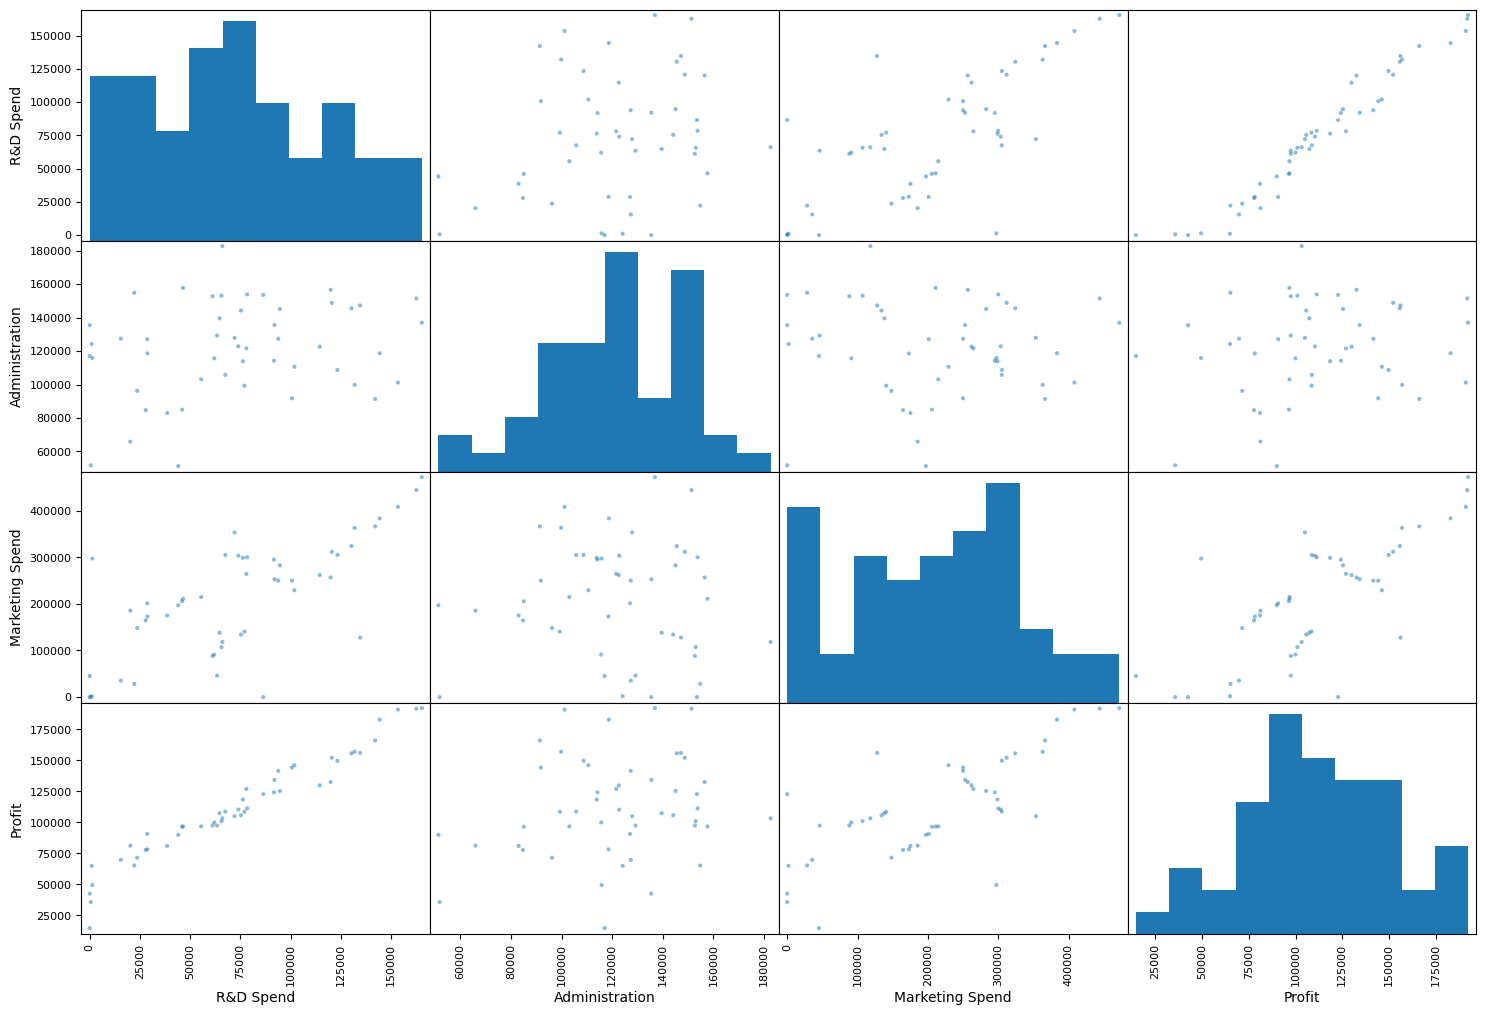

In [ ]:
from pandas.plotting import scatter_matrix

#promissingFeatures = ['LifeExpectancy', 'Schooling', 'IncomeCompositionOfResources', 'BMI', 'HIVAIDS', 'AdultMortality']
scatter_matrix(dataset, figsize=(18, 12))
plt.show()

## Exercise:

1.   Explain the correlation matrix above
2.   Explain scatter plots above
1.   How are corellation value and scatter plots related?







## Splitting the dataset

In [ ]:
# Import train_test_split.
from sklearn.model_selection import train_test_split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### Excercise:



1.   List each of `X_train`, `X_test`, `y_train`and `y_test` by making code cells as done for `X_train` belo


1.   Comment on whether the test sets are representative







In [ ]:
X_train

,R&D Spend,Administration,Marketing Spend
12,93863.75,127320.38,249839.44
4,142107.34,91391.77,366168.42
37,44069.95,51283.14,197029.42
8,120542.52,148718.95,311613.29
3,144372.41,118671.85,383199.62
6,134615.46,147198.87,127716.82
41,27892.92,84710.77,164470.71
46,1315.46,115816.21,297114.46
47,0.00,135426.92,0.00
15,114523.61,122616.84,261776.23


## Linear regression

In [ ]:
# Import LinearRegression.
from sklearn.linear_model import LinearRegression


# Instantiate linear regression model.
model = LinearRegression()

In [ ]:
# Fit the model to the training data.
model.fit(X_train, y_train)

LinearRegression()

In [ ]:
# Make predictions on the testing data.
y_pred = model.predict(X_test)

In [ ]:
from sklearn.metrics import mean_squared_error

# Calculate and print MSE.
mse = mean_squared_error(y_test, y_pred)
print(f"Mean squared error: {mse:.4f}")


# Calculate and print RMSE.
rmse = mse ** 0.5
print(f"Root mean squared error: {rmse:.4f}")

Mean squared error: 80926321.2230
Root mean squared error: 8995.9058


### Exercise:

1.   Explain `mean_square_error` above related to the case
1.   Can you obtain better `mean_square_error` be removing some features?







## Model-coefficients

In [ ]:
print("Intercept:", model.intercept_)


coef_df = pd.DataFrame({"Feature": X.columns, "Coefficient": model.coef_})
print("\nFeature Coefficients:\n", coef_df)

Intercept: 54071.87574599082

Feature Coefficients:
            Feature  Coefficient
0        R&D Spend     0.803779
1   Administration    -0.067929
2  Marketing Spend     0.031242


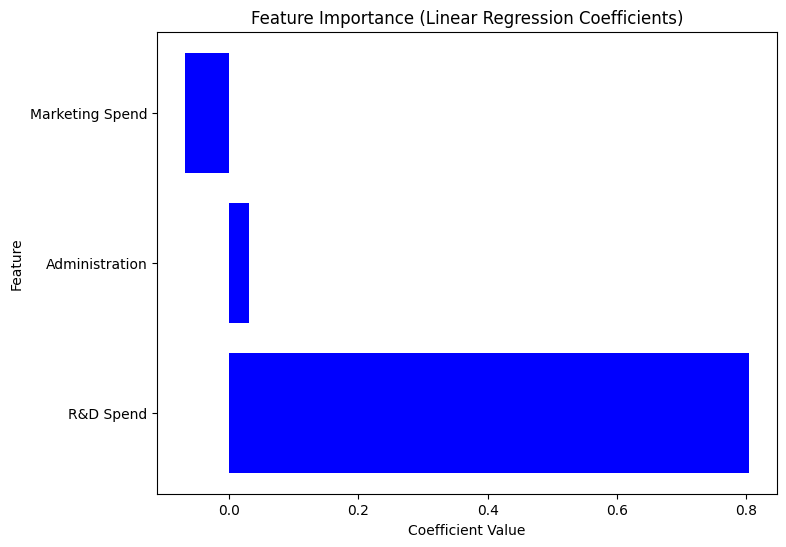

In [ ]:
# Sort dataframe by coefficients.
coef_df_sorted = coef_df.sort_values(by="Coefficient", ascending=False)


# Create plot.
plt.figure(figsize=(8,6))
plt.barh(coef_df["Feature"], coef_df_sorted["Coefficient"], color="blue")
plt.xlabel("Coefficient Value")
plt.ylabel("Feature")
plt.title("Feature Importance (Linear Regression Coefficients)")
plt.show()

### Exercise:

1.   Conclude on the Coefficient values:







